# Open the ASCII exported file

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr
import pandas as pd
%matplotlib widget

def heatmap_interactive(_x, _y, _data, _title, _cmap='jet', _symlog=False, _linthresh=1.0,_loglog=False, _lines = False):
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.5], height_ratios=[0.5, 1], hspace=0.2, wspace=0.2)
    ax_main = plt.subplot(gs[1, 0])
    main_plot = ax_main.pcolormesh(_x, _y, _data, cmap=_cmap)
    ax_main.set(ylabel='Delay / ps', xlabel='Wavelength / nm')
    # set mixed log-lin scale with threshold value linthresh
    if _loglog:
        ax_main.set_xscale('log')
        ax_main.set_yscale('log')
    elif _symlog:
        ax_main.set_yscale('symlog', linthresh=_linthresh)
    # set axis range to min and max values
    ax_main.set_xlim(_x[0],_x[-1])
    ax_main.set_ylim(_y[0],_y[-1]) 

    if _lines:
        # Overlay contour lines
        levels = np.linspace(np.min(_data), np.max(_data), 12)
        contour = ax_main.contour(_x, _y, _data, levels=levels, colors='black', linewidths=0.5)
        ax_main.clabel(contour, fmt="%.0e", fontsize=8)

    ax_kin = plt.subplot(gs[0, 0])
    line_kin, = ax_kin.plot(_x,np.zeros(_x.shape))
    kin_zero_line, = ax_kin.plot([_x[0],_x[-1]],[0,0], color="0.6")
    ax_kin.set_xlim(_x[0],_x[-1])
    # Kinetics plot y-axis (intensity)
    if _loglog:
        ax_kin.set_yscale('linear')  # keep linear, unless you want to log this too
    elif _symlog:
        ax_kin.set_yscale('symlog', linthresh=_linthresh)

    ax_spec = plt.subplot(gs[1, 1])
    line_spec, = ax_spec.plot(np.zeros(_y.shape),_y)
    spec_zero_line, = ax_spec.plot([0,0],[_y[0],_y[-1]], color="0.6")
    ax_spec.set_ylim(_y[0],_y[-1])        
    
    # This lower bounds list is necessary because the blocks in the 2D-plot cover a certain range
    def create_lower_bounds(_value_list):
        result = np.empty_like(_value_list)
        #first lower bound is equal to the lowest value in the nm-list
        result[0] = _value_list[0]
        #example: lower bound for 100 ps is 97.5 ps if the value prior is 95 ps, and 75 ps if the value prior is 50 ps.
        for i in range(1,len(_value_list)):
            result[i] = (_value_list[i]+_value_list[i-1])/2
        return result    
    
    nm_lower_bounds = create_lower_bounds(_y)
    time_lower_bounds = create_lower_bounds(_x)
    
    def nm_to_index(_nm):
        return np.where(_nm > nm_lower_bounds)[0][-1]
    
    def time_to_index(_time):
        return np.where(_time > time_lower_bounds)[0][-1]
    
    def mouse_move(event):
        x = event.xdata
        y = event.ydata
        if x is not None and y is not None:
            if x>=_x[0] and x<=_x[-1] and y>=_y[0] and y<=_y[-1]:
                # update spectra slice and rescale
                new_spec = _data[:,time_to_index(x)]
                line_spec.set_xdata(new_spec)
                spec_bounds = ax_spec.get_ylim()
                spec_range = new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].max()-new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].min()
                ax_spec.set_xlim(new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].min()-0.1*spec_range,new_spec[(_y>=spec_bounds[0]) & (_y<=spec_bounds[1])].max()+0.1*spec_range)            

                # update kinetic slice and rescale
                new_kin = _data[nm_to_index(y),:]
                line_kin.set_ydata(new_kin)
                kin_bounds = ax_kin.get_xlim()  
                kin_range = new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].max()-new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].min()                
                ax_kin.set_ylim(new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].min()-0.1*kin_range,new_kin[(_x>=kin_bounds[0]) & (_x<=kin_bounds[1])].max()+0.1*kin_range)
                
                # redraw figure
                fig.canvas.draw_idle()
             
    fig.canvas.mpl_connect('motion_notify_event', mouse_move) 
    
    # find max absolute value of 2D data in the specified zoom mode of the plot
    def get_maxvalue(_xlim, _ylim, _xvals, _yvals, _data_array):
        y_filter = (_yvals>=_ylim[0]) & (_yvals<=_ylim[1])
        x_filter = (_xvals>=_xlim[0]) & (_xvals<=_xlim[1])
        
        if not np.all(y_filter == False) and not np.all(x_filter == False):
            return np.amax(np.abs(_data_array[y_filter][:,x_filter]))
        else:
            return 0
    
    def on_xlims_change(event_ax):
        ax_kin.set_xlim(event_ax.get_xlim())
        
        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_x,_y,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)

    def on_ylims_change(event_ax):
        ax_spec.set_ylim(event_ax.get_ylim())
        
        new_max = get_maxvalue(event_ax.get_xlim(),event_ax.get_ylim(),_x,_y,_data)
        if new_max > 0:
            main_plot.set_clim(vmin=-new_max, vmax=new_max)        

    ax_main.callbacks.connect('xlim_changed', on_xlims_change)
    ax_main.callbacks.connect('ylim_changed', on_ylims_change)
    main_plot.set_clim(vmin=np.min(_data), vmax=np.max(_data))
    fig.colorbar(main_plot, ax=[ax_main, ax_spec], orientation='vertical', label='Intensity (a.u.)')
    plt.show(block=False)




# Open Ldm files

In [130]:
# Load the .ldm file assuming it's space-separated and has no header
filename = '/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Ana files/Full_spectrum/LDA_Results/dataset_dpp_lda_01_086.ldm'
data = pd.read_csv(filename, delim_whitespace=True, header=None, names=['lifetime','wavelength', 'intensity'])

# Extract unique coordinates
wavelengths = np.sort(data['wavelength'].unique())
lifetimes = np.sort(data['lifetime'].unique())

# Pivot the data into a 2D grid: rows -> wavelength, columns -> lifetime
intensity_grid = data.pivot(index='wavelength', columns='lifetime', values='intensity').to_numpy()

# Create xarray DataArray
da = xr.DataArray(
    intensity_grid,
    coords={'wavelength': wavelengths, 'lifetime': lifetimes},
    dims=['wavelength', 'lifetime'],
    name='intensity'
)

# Convert to xarray Dataset
ds_dpp = xr.Dataset({'intensity': da})

# Display dataset
ds_dpp


/var/folders/ml/80b1_jpx6vq4f5c9t3n9yxh00000gn/T/ipykernel_8887/3269477954.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(filename, delim_whitespace=True, header=None, names=['lifetime','wavelength', 'intensity'])


<xarray.Dataset> Size: 292kB
Dimensions:     (wavelength: 150, lifetime: 241)
Coordinates:
  * wavelength  (wavelength) float64 1kB 0.01 0.01059 0.01121 ... 47.22 50.0
  * lifetime    (lifetime) float64 2kB 464.9 465.1 465.4 ... 519.6 519.9 520.1
Data variables:
    intensity   (wavelength, lifetime) float64 289kB 7.767e-09 ... 0.0001535

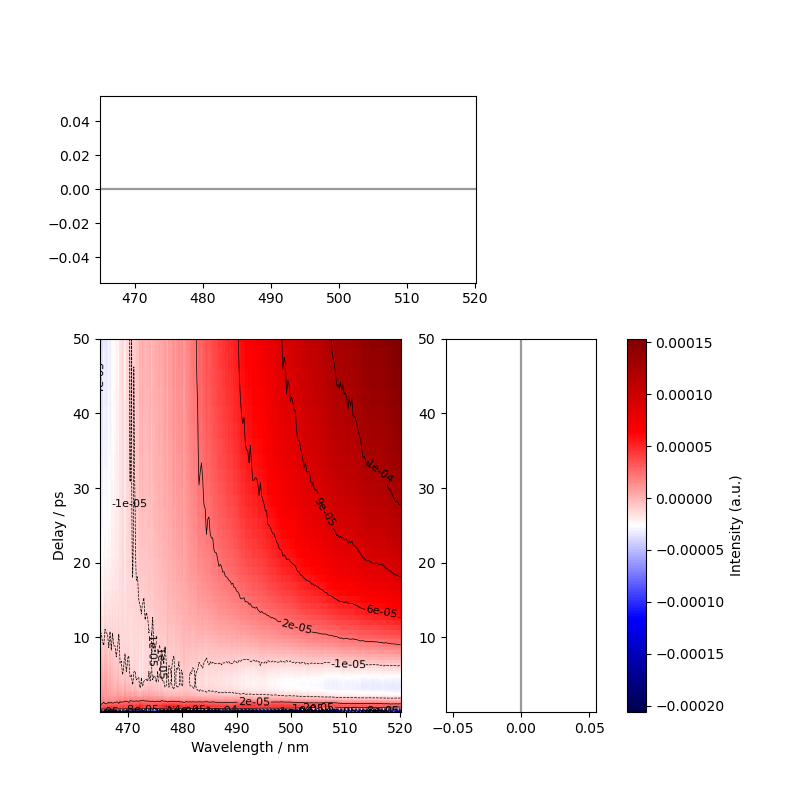

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

In [131]:
heatmap_interactive(ds_dpp.lifetime,ds_dpp.wavelength, ds_dpp['intensity'].transpose('wavelength','lifetime'),'Averaged scan plot',_loglog=False,_cmap='seismic',_lines = True) #dpp

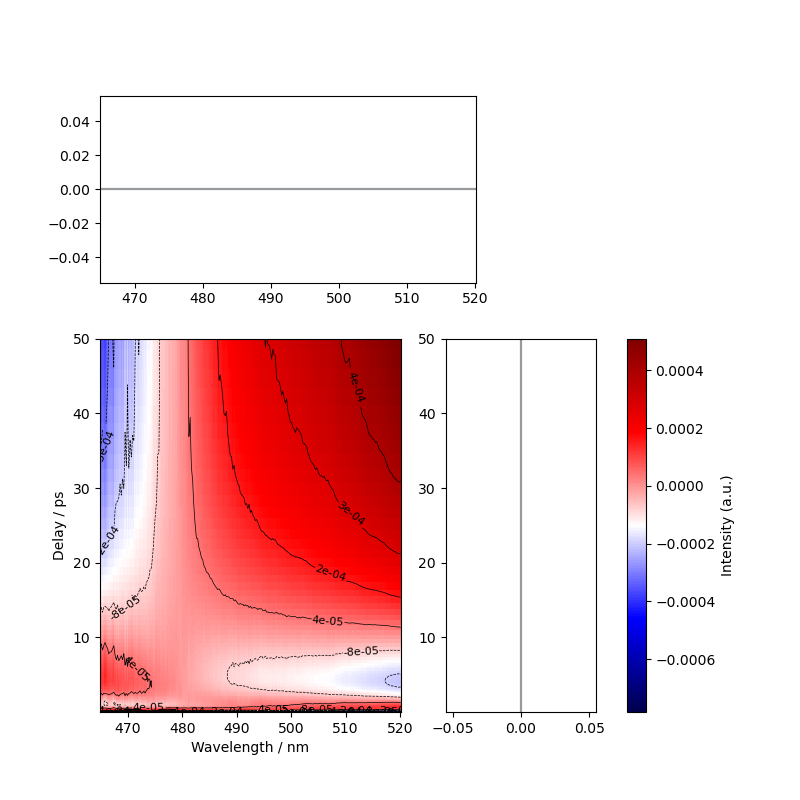

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

...

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

In [129]:
heatmap_interactive(ds_dchtmp.lifetime,ds_dchtmp.wavelength, ds_dchtmp['intensity'].transpose('wavelength','lifetime'),'Averaged scan plot',_loglog=False,_cmap='seismic',_lines = True) #dchtmp

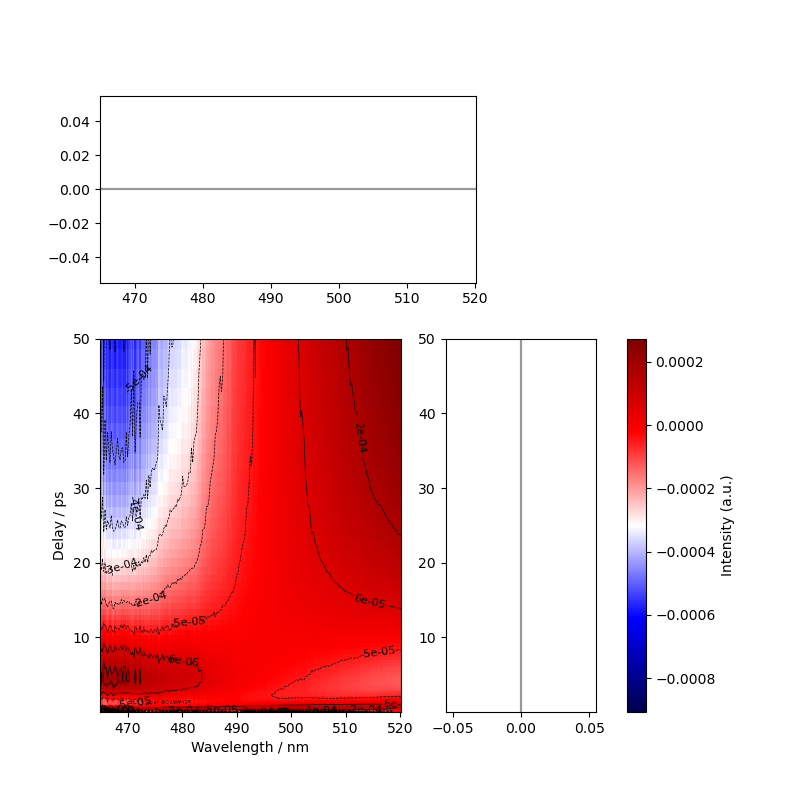

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

...

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

In [125]:
heatmap_interactive(ds.lifetime,ds.wavelength, ds['intensity'].transpose('wavelength','lifetime'),'Averaged scan plot',_loglog=False,_cmap='seismic',_lines = True) #dmp

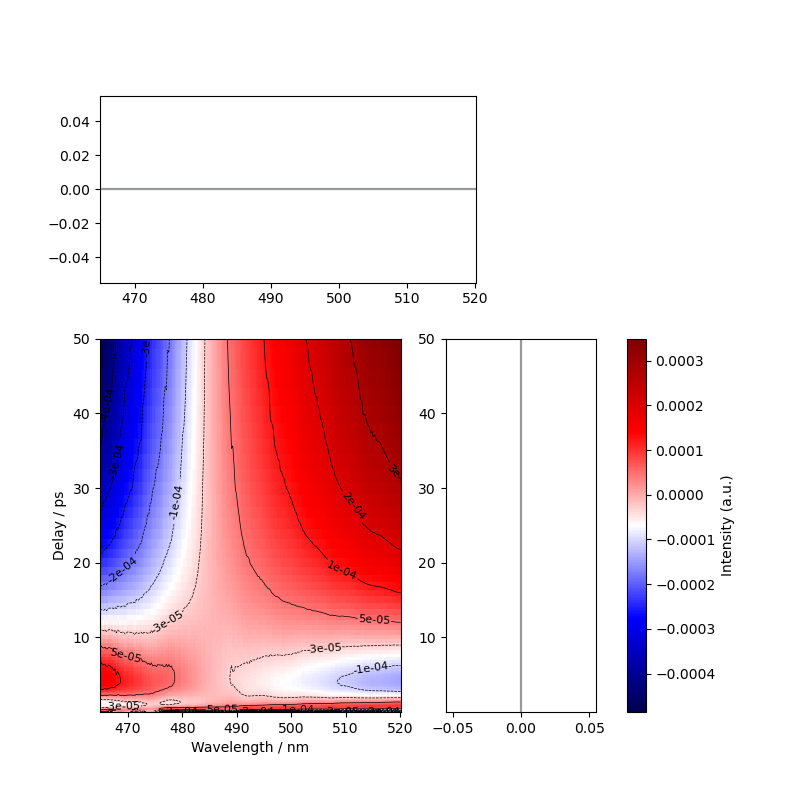

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

...

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

IndexError: index -1 is out of bounds for axis 0 with size 0

In [127]:
heatmap_interactive(ds.lifetime,ds.wavelength, ds['intensity'].transpose('wavelength','lifetime'),'Averaged scan plot',_loglog=False,_cmap='seismic',_lines = True) #dipp

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


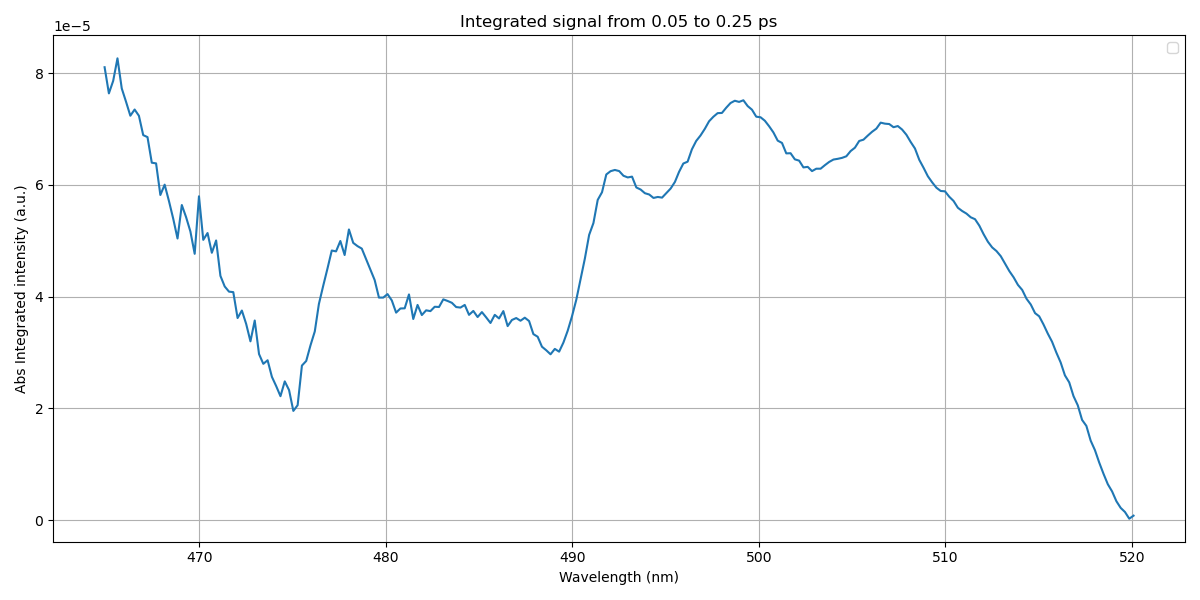

In [47]:
upper_time = 0.250
lower_time = 0.05

section = ds.sel(lifetime = slice(lower_time,upper_time))
integral = section.integrate(coord='lifetime')

# Plot result vs wavelength
plt.figure(figsize=(12, 6))
plt.plot(integral['wavelength'], np.abs(integral['intensity']))
plt.xlabel('Wavelength (nm)')
plt.ylabel('Abs Integrated intensity (a.u.)')
plt.title(f'Integrated signal from {lower_time} to {upper_time} ps')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Open 3D data map

In [120]:
import pandas as pd
import numpy as np
import xarray as xr

# Step 1: Load file
filename = '/Users/vard/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Ana files/Full_spectrum/CA_Fit/dataset_dpp_replicate_gla_01_001.dst_c'

df = pd.read_csv(filename, delim_whitespace=True, header=None, names=['lifetime', 'wavelength', 'intensity'])

trace_length = 187  # Corrected block size
num_traces = df.shape[0] // trace_length

# Extract coordinates
lifetimes = df['lifetime'].values[:trace_length]
wavelengths = df['wavelength'].values[::trace_length]

# Reshape the intensity array
intensity_values = df['intensity'].values.reshape((num_traces, trace_length))

# Create xarray DataArray
da = xr.DataArray(
    data=intensity_values,
    coords={'wavelength': wavelengths, 'lifetime': lifetimes},
    dims=['wavelength', 'lifetime'],
    name='intensity'
)
# Convert to xarray Dataset
dat = xr.Dataset({'intensity': da})



/var/folders/ml/80b1_jpx6vq4f5c9t3n9yxh00000gn/T/ipykernel_8887/1453881158.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, header=None, names=['lifetime', 'wavelength', 'intensity'])


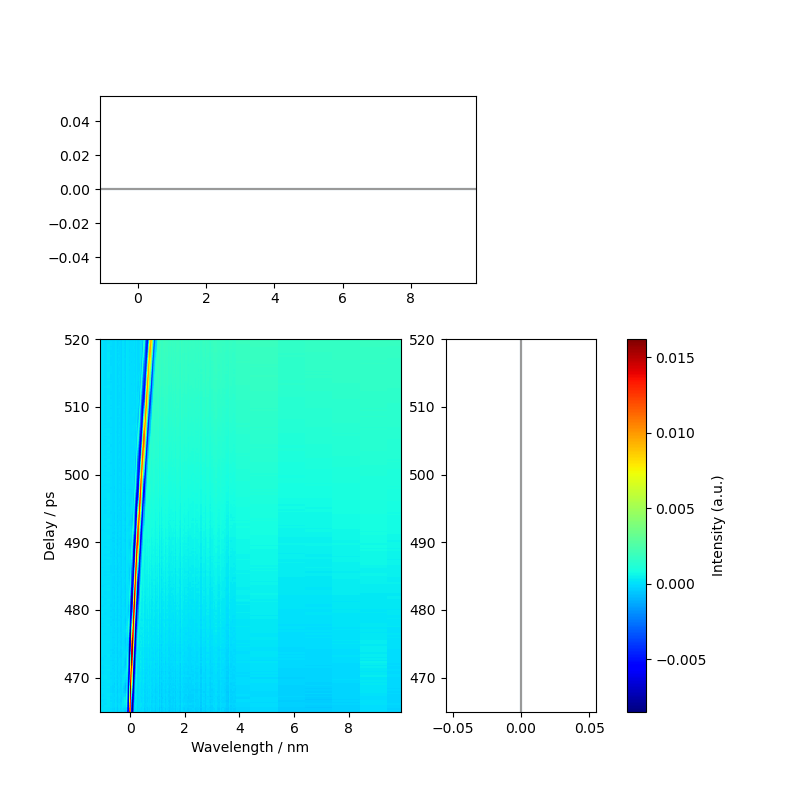

In [121]:
heatmap_interactive(dat.lifetime, dat.wavelength, dat['intensity'].transpose('wavelength','lifetime'),'Averaged scan plot',_symlog=False)

In [98]:
da

<xarray.DataArray 'intensity' (wavelength: 241, lifetime: 187)> Size: 361kB
array([[-9.00e-05, -4.00e-05,  1.10e-04, ..., -3.00e-04, -7.00e-05,
        -2.10e-04],
       [-1.60e-04,  8.00e-05,  4.00e-05, ..., -3.30e-04, -8.00e-05,
        -2.50e-04],
       [-7.00e-05,  1.00e-04,  5.00e-05, ..., -3.50e-04, -4.00e-05,
        -3.20e-04],
       ...,
       [-6.00e-05,  5.00e-05, -0.00e+00, ...,  1.74e-03,  1.78e-03,
         1.76e-03],
       [-5.00e-05,  5.00e-05, -1.00e-05, ...,  1.74e-03,  1.77e-03,
         1.75e-03],
       [-5.00e-05,  4.00e-05,  0.00e+00, ...,  1.76e-03,  1.77e-03,
         1.76e-03]])
Coordinates:
  * wavelength  (wavelength) float64 2kB 464.9 465.1 465.4 ... 519.6 519.9 520.1
  * lifetime    (lifetime) float64 1kB -1.102 -1.002 -0.9017 ... 8.898 9.898